# 11d · EDA — Doom vs Animal Crossing Meme Classification

**Goal:** Understand the image dataset before modelling — class balance, file formats, visual properties (size, brightness, colour), and a sanity-check between train and test distributions.

Labels: `0 = Animal Crossing`, `1 = Doom`


In [3]:
# Install / upgrade dependencies if needed
!pip install -q tqdm pillow matplotlib seaborn

zsh:1: command not found: pip


## 0 · Imports & Paths

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Kaggle paths ───────────────────────────────────────────────────────────
BASE      = Path('.')          # adjust if needed
IMG_DIR   = BASE / 'img'               # folder containing all images
TRAIN_CSV = BASE / 'train-label.csv'
TEST_CSV  = BASE / 'test-label.csv'

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

LABEL_MAP = {0: 'Animal Crossing', 1: 'Doom'}
train['label_name'] = train['label'].map(LABEL_MAP)

print('Train:', train.shape, '| Test:', test.shape)
train.head()


Train: (1385, 4) | Test: (1386, 3)


,id,file,label,label_name
0,0,001bd5563b4511f0b16c00155d672fff.png,1,Doom
1,1,d13cde743b4411f0b16c00155d672fff.jpg,0,Animal Crossing
2,2,96f4bf1a3b4511f0b16c00155d672fff.jpg,1,Doom
3,3,43f18faa3b4511f0b16c00155d672fff.jpg,0,Animal Crossing
4,4,bf0df3a03b4411f0b16c00155d672fff.png,1,Doom


## 1 · Class Balance

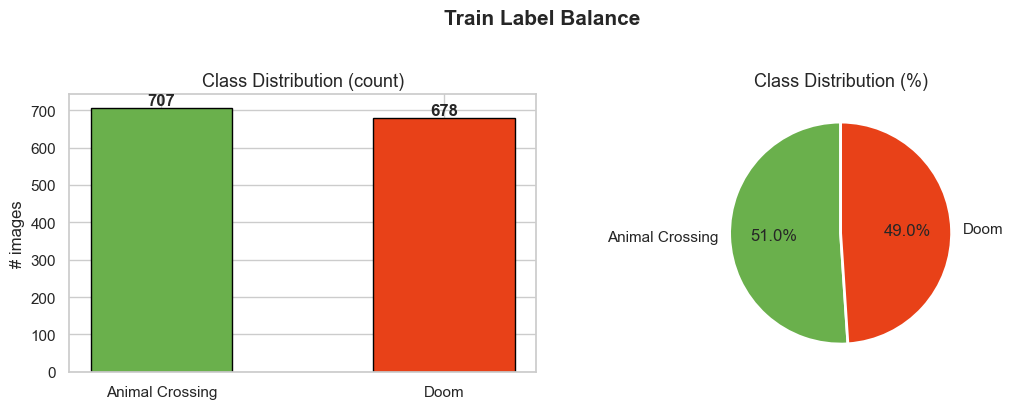

Animal Crossing: 707  (51.0%)
Doom:            678  (49.0%)
Balance ratio:   0.959  (1.0 = perfectly balanced)


In [5]:
counts = train['label_name'].value_counts()
pct    = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# bar
axes[0].bar(counts.index, counts.values, color=['#6ab04c','#e84118'], edgecolor='black', width=0.5)
for i, (n, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (count)', fontsize=13)
axes[0].set_ylabel('# images')

# pie
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#6ab04c','#e84118'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Train Label Balance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Animal Crossing: {counts['Animal Crossing']}  ({pct['Animal Crossing']:.1f}%)")
print(f"Doom:            {counts['Doom']}  ({pct['Doom']:.1f}%)")
print(f"Balance ratio:   {counts.min()/counts.max():.3f}  (1.0 = perfectly balanced)")


## 2 · File Format Distribution


Train file extensions:
file
jpg    1088
png     297

Test file extensions:
file
jpg    1115
png     271


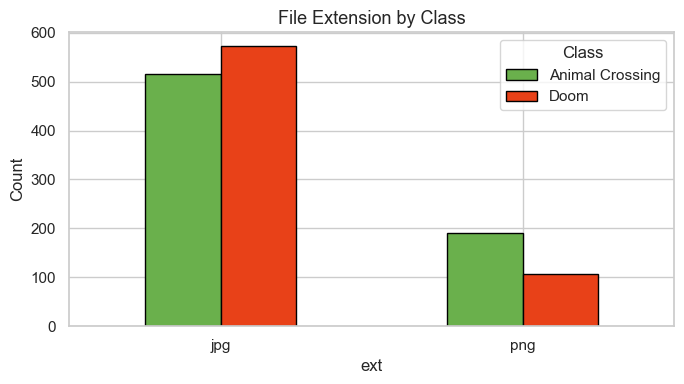

In [6]:
for split_name, df in [('Train', train), ('Test', test)]:
    ext = df['file'].str.split('.').str[-1].str.lower()
    print(f"\n{split_name} file extensions:")
    print(ext.value_counts().to_string())

# by class
train['ext'] = train['file'].str.split('.').str[-1].str.lower()
ct = pd.crosstab(train['ext'], train['label_name'])

ct.plot(kind='bar', figsize=(7, 4), color=['#6ab04c','#e84118'],
        edgecolor='black', rot=0)
plt.title('File Extension by Class', fontsize=13)
plt.ylabel('Count')
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## 3 · Sample Images per Class

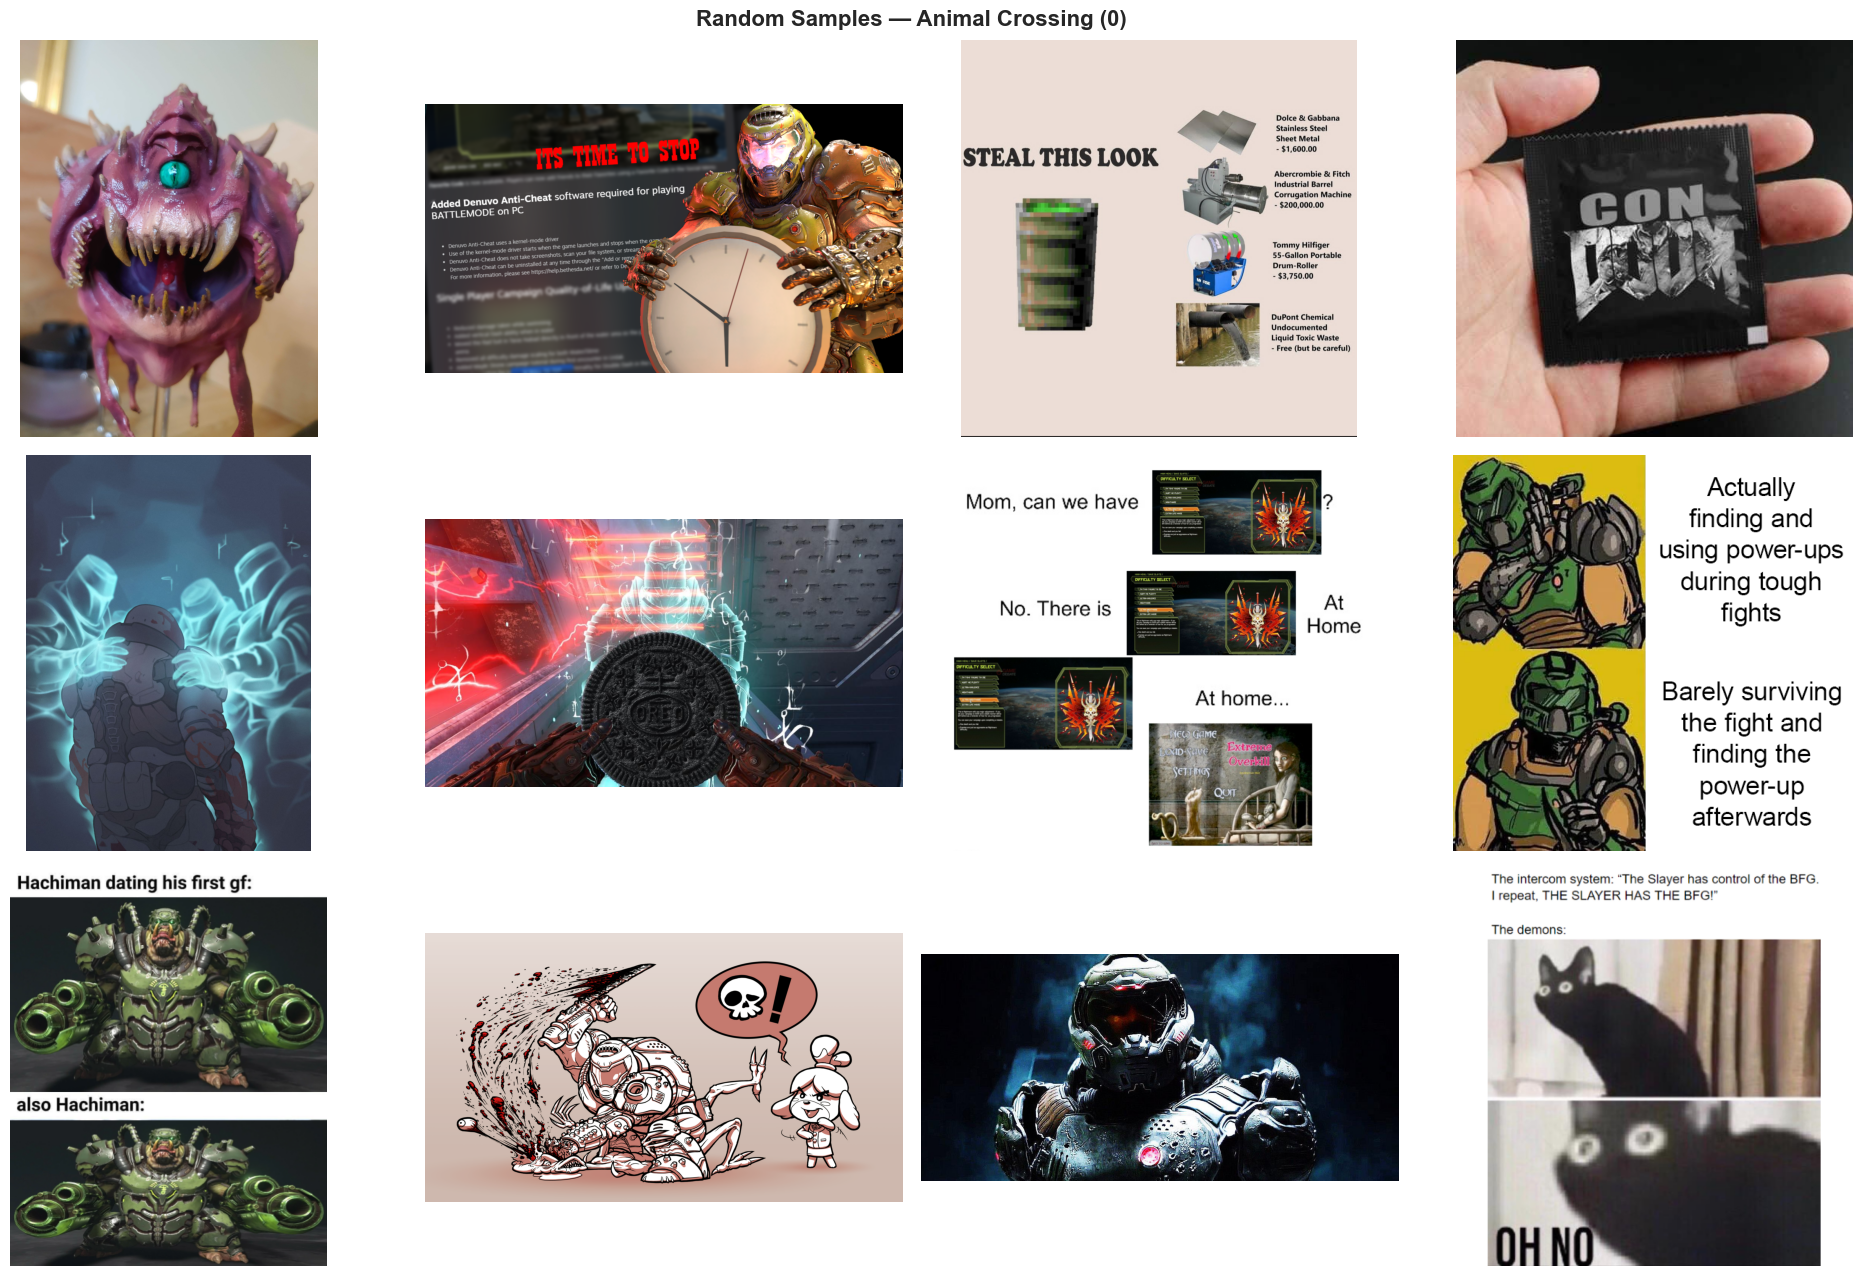

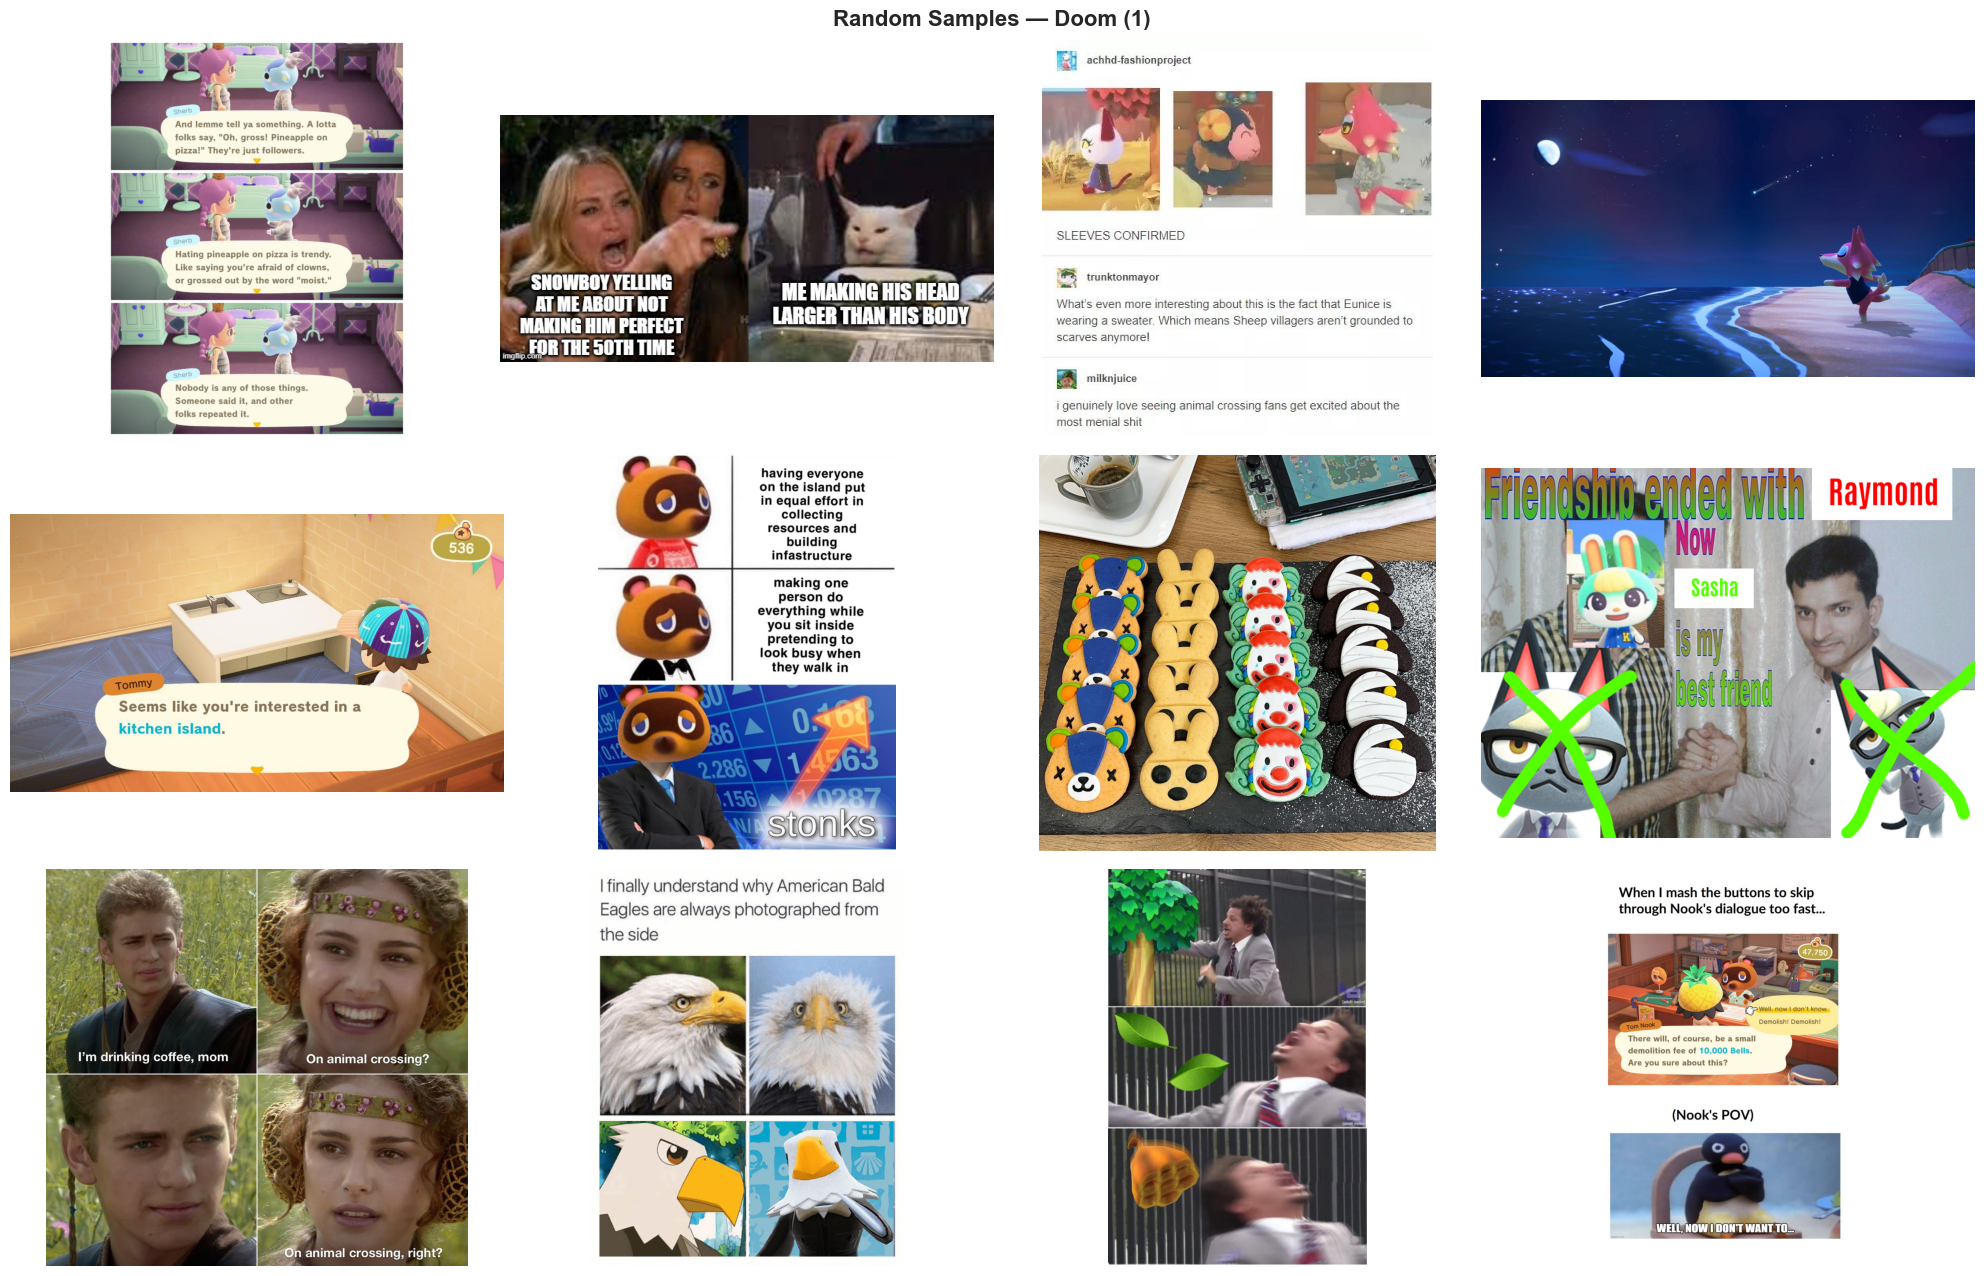

In [7]:
def show_samples(df, label, label_name, n=12, seed=42):
    np.random.seed(seed)
    subset = df[df['label'] == label].sample(n)
    rows, cols = 3, 4
    fig, axes = plt.subplots(rows, cols, figsize=(20, 13))
    fig.suptitle(f'Random Samples — {label_name}', fontsize=16, fontweight='bold')
    for ax, (_, row) in zip(axes.flat, subset.iterrows()):
        img_path = IMG_DIR / row['file']
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train, label=0, label_name='Animal Crossing (0)')
show_samples(train, label=1, label_name='Doom (1)')


## 4 · Image Size & Aspect Ratio

In [8]:
def collect_image_stats(df, img_dir, max_n=None):
    rows = []
    subset = df if max_n is None else df.sample(min(max_n, len(df)), random_state=42)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Loading images'):
        path = img_dir / row['file']
        try:
            with Image.open(path) as img:
                w, h = img.size
                rows.append({
                    'file':        row['file'],
                    'label':       row.get('label', -1),
                    'label_name':  LABEL_MAP.get(row.get('label', -1), 'Test'),
                    'width':       w,
                    'height':      h,
                    'aspect':      w / h,
                    'megapixels':  (w * h) / 1e6,
                })
        except Exception:
            pass
    return pd.DataFrame(rows)

stats_train = collect_image_stats(train, IMG_DIR)
stats_test  = collect_image_stats(test,  IMG_DIR)

print("Train image stats:")
print(stats_train[['width','height','aspect','megapixels']].describe().round(2))


Loading images: 100%|██████████| 1386/1386 [00:00<00:00, 4321.93it/s]

Train image stats:
         width   height   aspect  megapixels
count  1385.00  1385.00  1385.00     1385.00
mean   1346.80  1246.54     1.21        2.35
std     891.59   914.90     0.46        3.69
min     253.00   163.00     0.32        0.05
25%     750.00   674.00     0.88        0.54
50%    1080.00   928.00     1.05        0.92
75%    1500.00  1520.00     1.55        2.07
max    8000.00  6000.00     4.51       33.00


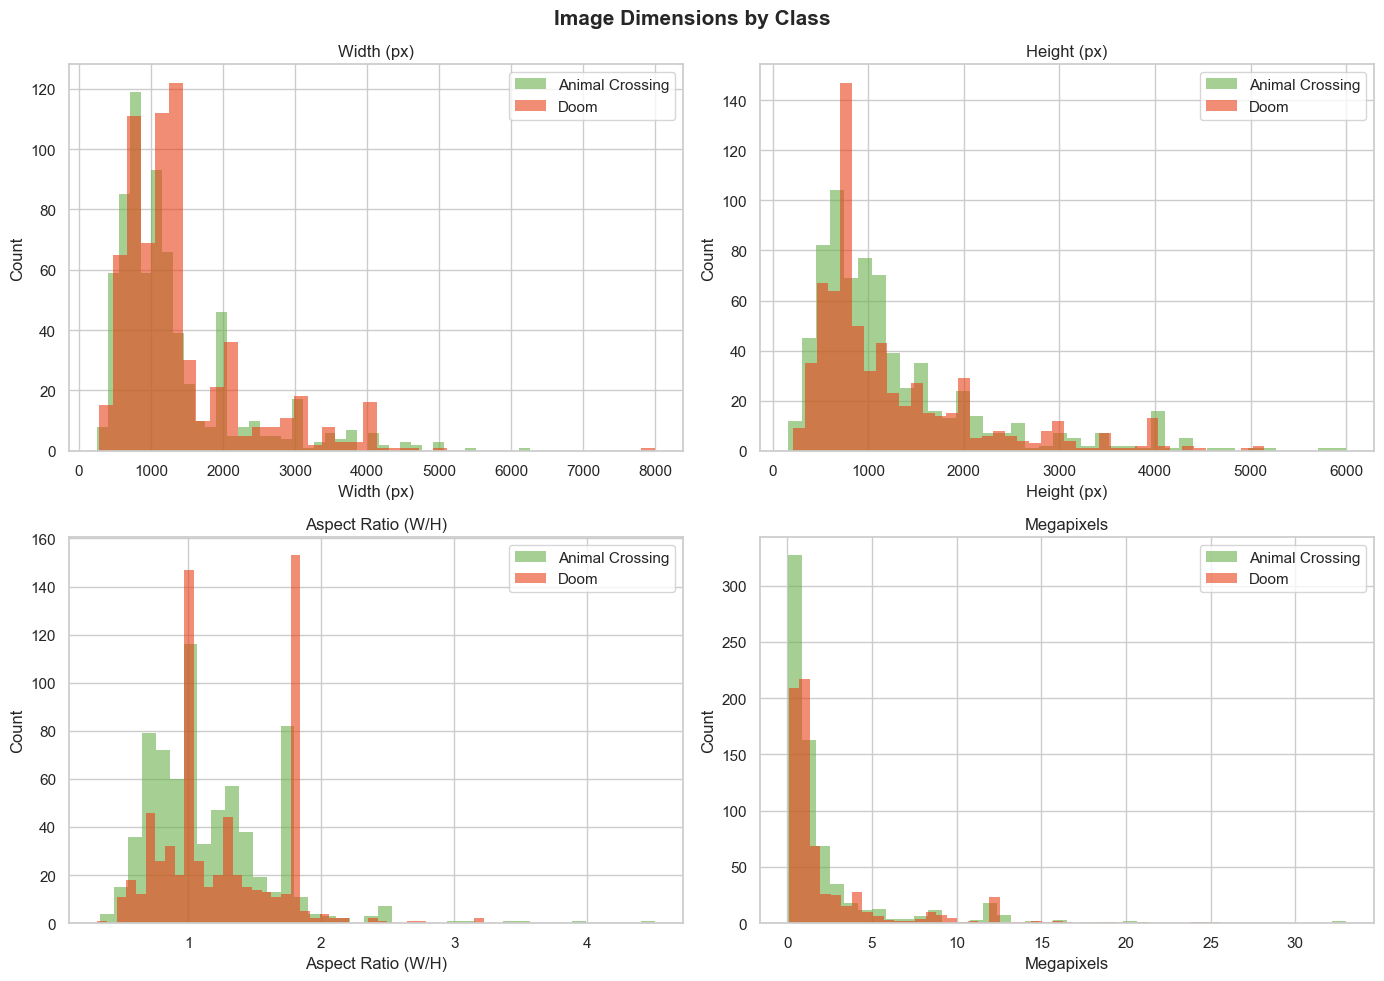

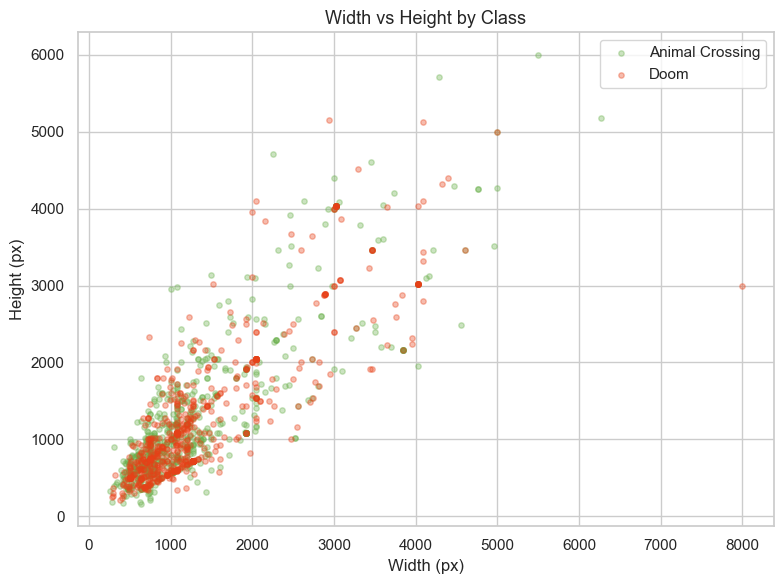

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Image Dimensions by Class', fontsize=15, fontweight='bold')

palette = {'Animal Crossing': '#6ab04c', 'Doom': '#e84118'}

for ax, col, title in zip(
        axes.flat,
        ['width', 'height', 'aspect', 'megapixels'],
        ['Width (px)', 'Height (px)', 'Aspect Ratio (W/H)', 'Megapixels']):
    for lname, grp in stats_train.groupby('label_name'):
        ax.hist(grp[col], bins=40, alpha=0.6, label=lname,
                color=palette[lname], edgecolor='none')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Scatter: width vs height coloured by class
fig, ax = plt.subplots(figsize=(8, 6))
for lname, grp in stats_train.groupby('label_name'):
    ax.scatter(grp['width'], grp['height'], alpha=0.35, s=15,
               label=lname, color=palette[lname])
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.set_title('Width vs Height by Class', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 5 · Brightness & Colour Analysis

Doom memes are expected to be **darker and more desaturated**; Animal Crossing bright and colourful. Let's verify.

In [10]:
def colour_stats(df, img_dir, max_n=500):
    rows = []
    subset = df.sample(min(max_n, len(df)), random_state=42)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Colour stats'):
        path = img_dir / row['file']
        try:
            img = Image.open(path).convert('RGB').resize((128, 128))
            arr = np.array(img, dtype=np.float32)
            r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
            brightness = arr.mean()
            # saturation approximation: (max - min) / max per pixel
            mx = arr.max(axis=2); mn = arr.min(axis=2)
            sat = np.where(mx > 0, (mx - mn) / mx, 0).mean()
            rows.append({
                'label':       row.get('label', -1),
                'label_name':  LABEL_MAP.get(row.get('label', -1), 'Test'),
                'brightness':  brightness,
                'saturation':  sat,
                'mean_r':      r.mean(),
                'mean_g':      g.mean(),
                'mean_b':      b.mean(),
                'std_r':       r.std(),
                'std_g':       g.std(),
                'std_b':       b.std(),
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

colour_train = colour_stats(train, IMG_DIR)
colour_test  = colour_stats(test,  IMG_DIR)


Colour stats: 100%|██████████| 500/500 [00:12<00:00, 39.29it/s]


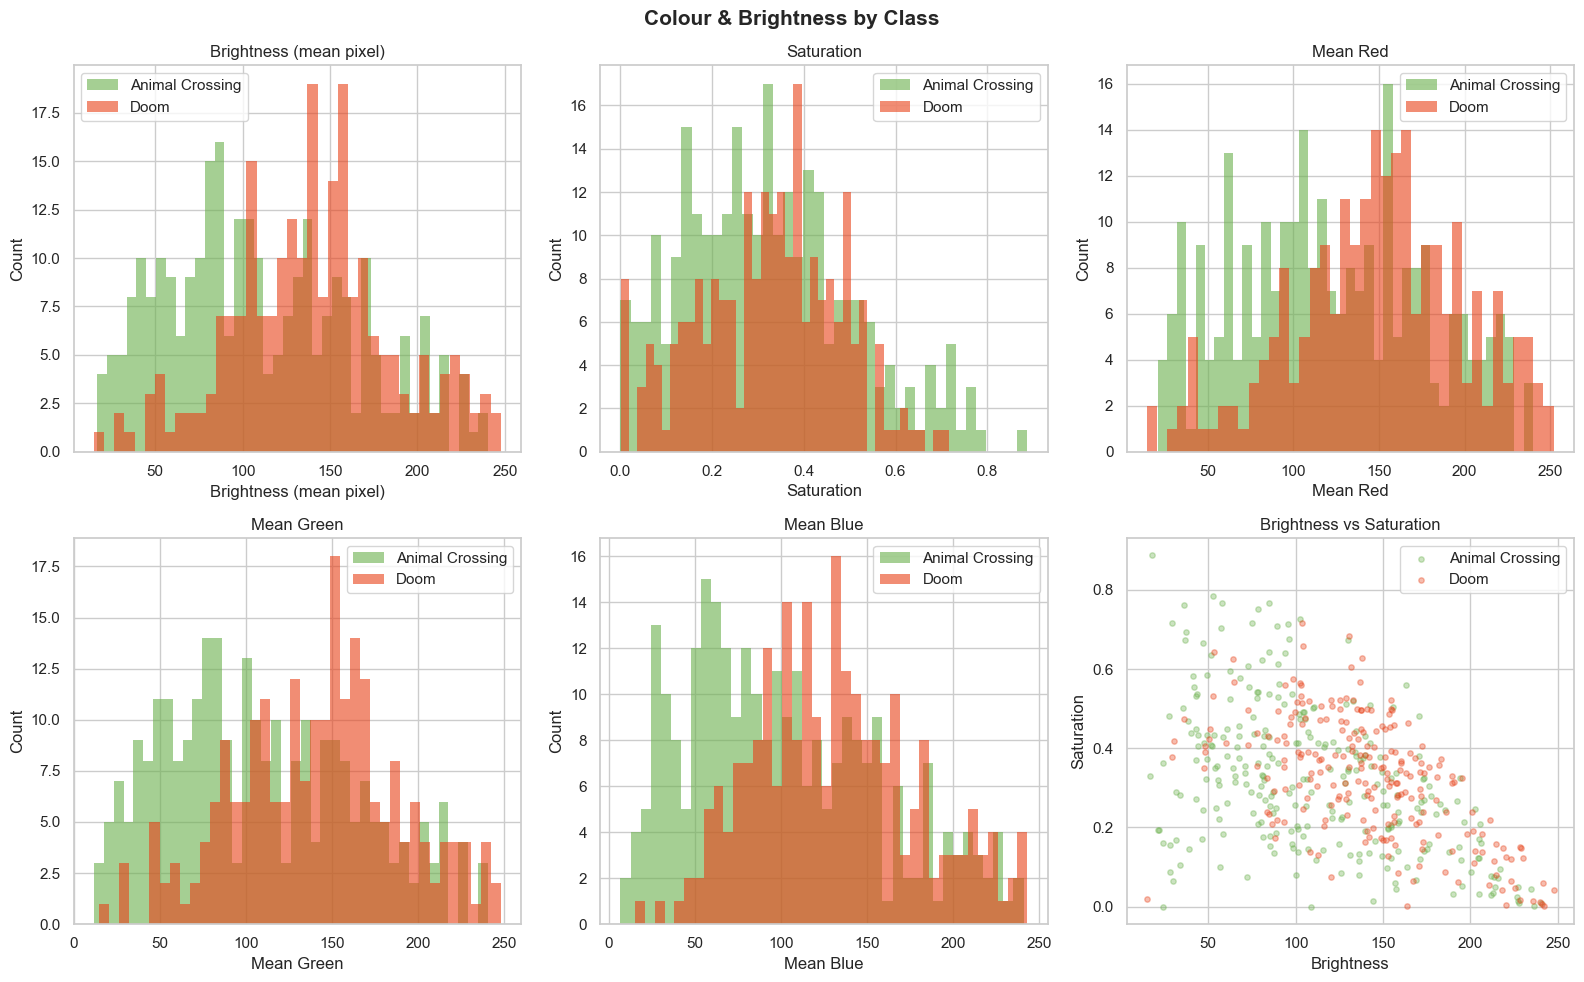

                 brightness  saturation      mean_r      mean_g      mean_b
label_name                                                                 
Animal Crossing  110.250000        0.32  122.129997  107.699997  100.919998
Doom             140.729996        0.32  149.490005  141.259995  131.449997


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Colour & Brightness by Class', fontsize=15, fontweight='bold')

metrics = ['brightness', 'saturation', 'mean_r', 'mean_g', 'mean_b']
titles  = ['Brightness (mean pixel)', 'Saturation', 'Mean Red', 'Mean Green', 'Mean Blue']

for ax, metric, title in zip(axes.flat, metrics, titles):
    for lname, grp in colour_train.groupby('label_name'):
        ax.hist(grp[metric], bins=40, alpha=0.6, label=lname,
                color=palette[lname], edgecolor='none')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend()

# last panel: scatter brightness vs saturation
ax = axes.flat[-1]
for lname, grp in colour_train.groupby('label_name'):
    ax.scatter(grp['brightness'], grp['saturation'], alpha=0.35, s=15,
               label=lname, color=palette[lname])
ax.set_xlabel('Brightness')
ax.set_ylabel('Saturation')
ax.set_title('Brightness vs Saturation', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print(colour_train.groupby('label_name')[['brightness','saturation','mean_r','mean_g','mean_b']].mean().round(2))


## 6 · Mean Image per Class

Average all images together — reveals dominant colours and rough spatial patterns.

Mean img label=1: 100%|██████████| 300/300 [00:07<00:00, 42.02it/s]


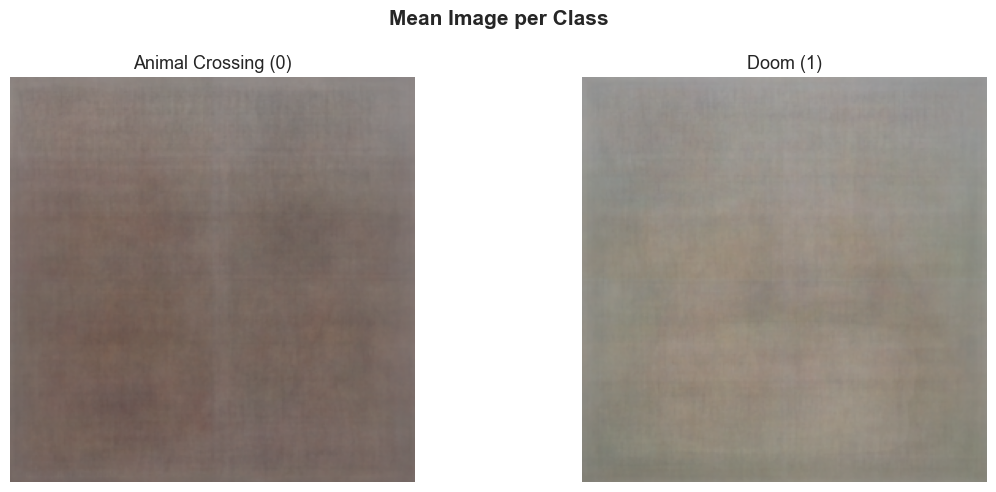

In [12]:
def mean_image(df, img_dir, label, size=(256, 256), max_n=300):
    subset = df[df['label'] == label].sample(min(max_n, len(df[df['label']==label])), random_state=42)
    stack = []
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f'Mean img label={label}'):
        path = img_dir / row['file']
        try:
            img = Image.open(path).convert('RGB').resize(size)
            stack.append(np.array(img, dtype=np.float32))
        except Exception:
            pass
    return np.mean(stack, axis=0).astype(np.uint8) if stack else None

mean_ac   = mean_image(train, IMG_DIR, label=0)
mean_doom = mean_image(train, IMG_DIR, label=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Mean Image per Class', fontsize=15, fontweight='bold')
for ax, img, title in zip(axes, [mean_ac, mean_doom], ['Animal Crossing (0)', 'Doom (1)']):
    if img is not None:
        ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 7 · Train vs Test Distribution Check

Make sure the test set looks similar to train — if not, our model may struggle to generalise.

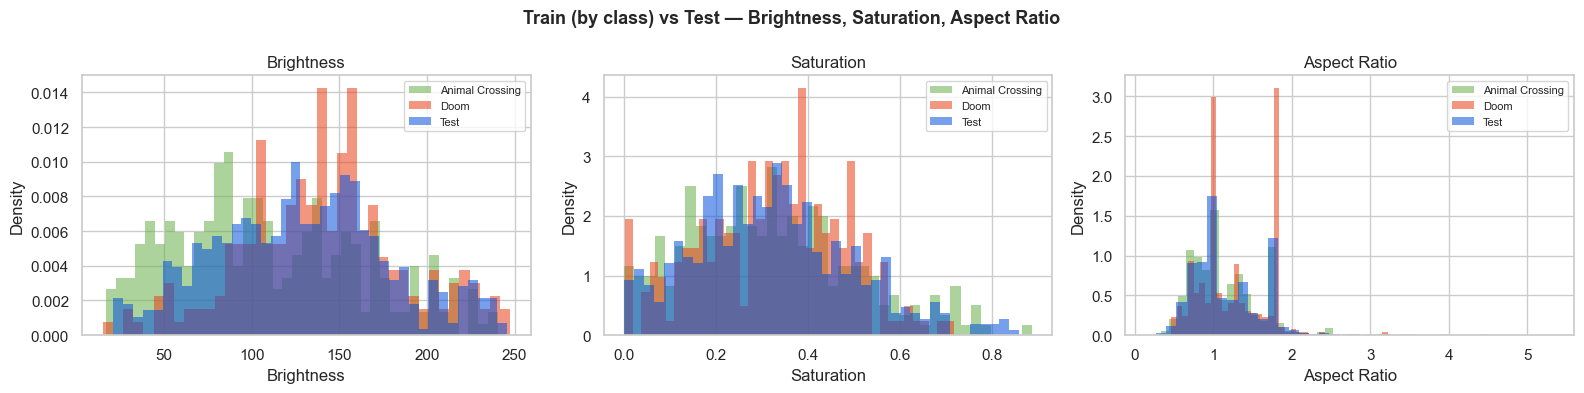


Brightness mean — Train AC / Train Doom / Test:
  Animal Crossing     : 110.25
  Doom                : 140.73
  Test                : 128.89


In [13]:
colour_test['label_name'] = 'Test'
combined = pd.concat([colour_train, colour_test], ignore_index=True)

palette3 = {'Animal Crossing': '#6ab04c', 'Doom': '#e84118', 'Test': '#0652DD'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Train (by class) vs Test — Brightness, Saturation, Aspect Ratio', fontsize=13, fontweight='bold')

# need aspect ratio for test too
stats_test['label_name'] = 'Test'
dim_combined = pd.concat([stats_train, stats_test], ignore_index=True)

for ax, (df_use, col, title) in zip(axes, [
        (combined,      'brightness', 'Brightness'),
        (combined,      'saturation', 'Saturation'),
        (dim_combined,  'aspect',     'Aspect Ratio'),
    ]):
    for lname, grp in df_use.groupby('label_name'):
        ax.hist(grp[col], bins=40, alpha=0.55, label=lname,
                color=palette3.get(lname, 'grey'), edgecolor='none', density=True)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nBrightness mean — Train AC / Train Doom / Test:")
for g, d in combined.groupby('label_name'):
    print(f"  {g:20s}: {d['brightness'].mean():.2f}")


## 8 · Key EDA Findings & Modelling Implications

| Observation | Implication |
|---|---|
| Classes are near-balanced (707 vs 678) | No need for class weighting or oversampling |
| Mix of JPG and PNG, distribution similar across classes | Safe to treat uniformly; convert all to RGB |
| Doom images expected to be darker & less saturated | Colour/brightness features could be useful even for simple baselines |
| Mean image reveals dominant hue per class | CNN will naturally pick this up; helps confirm data is clean |
| Train and test brightness/saturation distributions overlap well | No obvious domain shift — standard train/val split should be reliable |

### Next Steps
1. Build a **baseline CNN** (ResNet18 or EfficientNet-B0) fine-tuned on train images
2. Consider adding **brightness + saturation** as auxiliary features if using a hybrid model
3. Use **stratified k-fold** (label balance is fine, but consistency matters)
4. Evaluate with **balanced accuracy** to stay robust to any minor imbalance


## 9 · Generate Dummy Submission (`submission11.csv`)

All-zero placeholder so you can verify the submission format immediately.

In [14]:
test_csv = pd.read_csv(TEST_CSV)
submission = pd.DataFrame({
    'id':    test_csv['id'],
    'label': 0              # placeholder — replace with model predictions
})
submission.to_csv('submission11.csv', index=False)
print(submission.head(10))
print(f"\nSaved submission11.csv — {len(submission)} rows")


     id  label
0  2078      0
1  2079      0
2  2080      0
3  2081      0
4  2082      0
5  2083      0
6  2084      0
7  2085      0
8  2086      0
9  2087      0

Saved submission11.csv — 1386 rows
